<a href="https://colab.research.google.com/github/Nikita1532001/real-time-project/blob/main/stock_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Stock Price Dashboard — Full Project
> **ML Fresher Project** | yfinance + pandas + matplotlib + sklearn

### 📌 Project :
- ✅ Live stock data fetch (yfinance)
- ✅ Data visualization (matplotlib / plotly)
- ✅ Moving Average ML prediction
- ✅ LSTM Neural Network prediction
- ✅ Buy / Sell / Hold signal
- ✅ Interactive Streamlit dashboard code


## ⚙️ Step 1 — Libraries Install

In [1]:

!pip install yfinance pandas numpy matplotlib seaborn scikit-learn tensorflow plotly streamlit -q
print('✅ libraries install !')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 51.2 MB/s eta 0:00:00
✅ libraries install !


## 📦 Step 2 — Imports

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('dark_background')
sns.set_palette('husl')

print('✅ all imports done!')

✅ all imports done!


## 📥 Step 3 — Live Stock Data Fetch करा

In [15]:
# ==============================
# Stock selected— they can changes!
# NSE India: RELIANCE.NS, TCS.NS, INFY.NS, WIPRO.NS, HDFCBANK.NS
# US Stocks: AAPL, GOOGL, TSLA, MSFT, AMZN
# ==============================
STOCK_SYMBOL = 'TCS.NS'   # <-- change
STOCK_NAME   = 'TCS'
PERIOD       = '6mo'       # 1mo, 3mo, 6mo, 1y, 2y

# Data fetch
ticker = yf.Ticker(STOCK_SYMBOL)
df = ticker.history(period=PERIOD)

# Index reset
df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)

print(f'✅ {STOCK_NAME} data fetch done!')
print(f'📅 Period: {df["Date"].min().date()} ते {df["Date"].max().date()}')
print(f'📊 Total rows: {len(df)}')
df.tail()

✅ TCS data fetch done!
📅 Period: 2025-10-30 ते 2026-04-30
📊 Total rows: 123


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
118,2026-04-24,2488.000000,2505.000000,2388.800049,2396.899902,5107719,0.0,0.0
119,2026-04-27,2396.899902,2459.000000,2396.899902,2447.600098,5853425,0.0,0.0
120,2026-04-28,2444.000000,2487.000000,2427.399902,2444.699951,4508363,0.0,0.0
121,2026-04-29,2451.000000,2487.899902,2447.600098,2474.699951,2835961,0.0,0.0
122,2026-04-30,2479.000000,2479.000000,2438.000000,2440.300049,1288187,0.0,0.0


## 🔍 Step 4 — Data Analysis (EDA)

In [4]:
# Basic statistics
print('=== Basic Statistics ===')
print(df[['Open','High','Low','Close','Volume']].describe().round(2))

print(f'\n📈 Highest Price : ₹{df["High"].max():.2f}  on {df.loc[df["High"].idxmax(),"Date"].date()}')
print(f'📉 Lowest Price  : ₹{df["Low"].min():.2f}  on {df.loc[df["Low"].idxmin(),"Date"].date()}')
print(f'📊 Avg Volume    : {df["Volume"].mean():,.0f}')
total_return = ((df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0]) * 100
print(f'💰 Total Return  : {total_return:.2f}%')

=== Basic Statistics ===
          Open     High      Low    Close       Volume
count   123.00   123.00   123.00   123.00       123.00
mean   2876.13  2899.94  2844.90  2870.14   3453404.67
std     307.27   302.79   306.33   306.29   1894758.41
min    2365.00  2398.00  2346.20  2356.00         0.00
25%    2571.00  2591.50  2543.25  2566.45   2300452.00
50%    2990.63  3011.60  2971.09  2991.50   2918730.00
75%    3152.14  3175.48  3127.50  3149.68   4207719.00
max    3350.00  3350.00  3237.25  3265.54  11168735.00

📈 Highest Price : ₹3350.00  on 2026-02-03
📉 Lowest Price  : ₹2346.20  on 2026-03-30
📊 Avg Volume    : 3,453,405
💰 Total Return  : -18.08%


## 📊 Step 5 — Price Chart + Volume

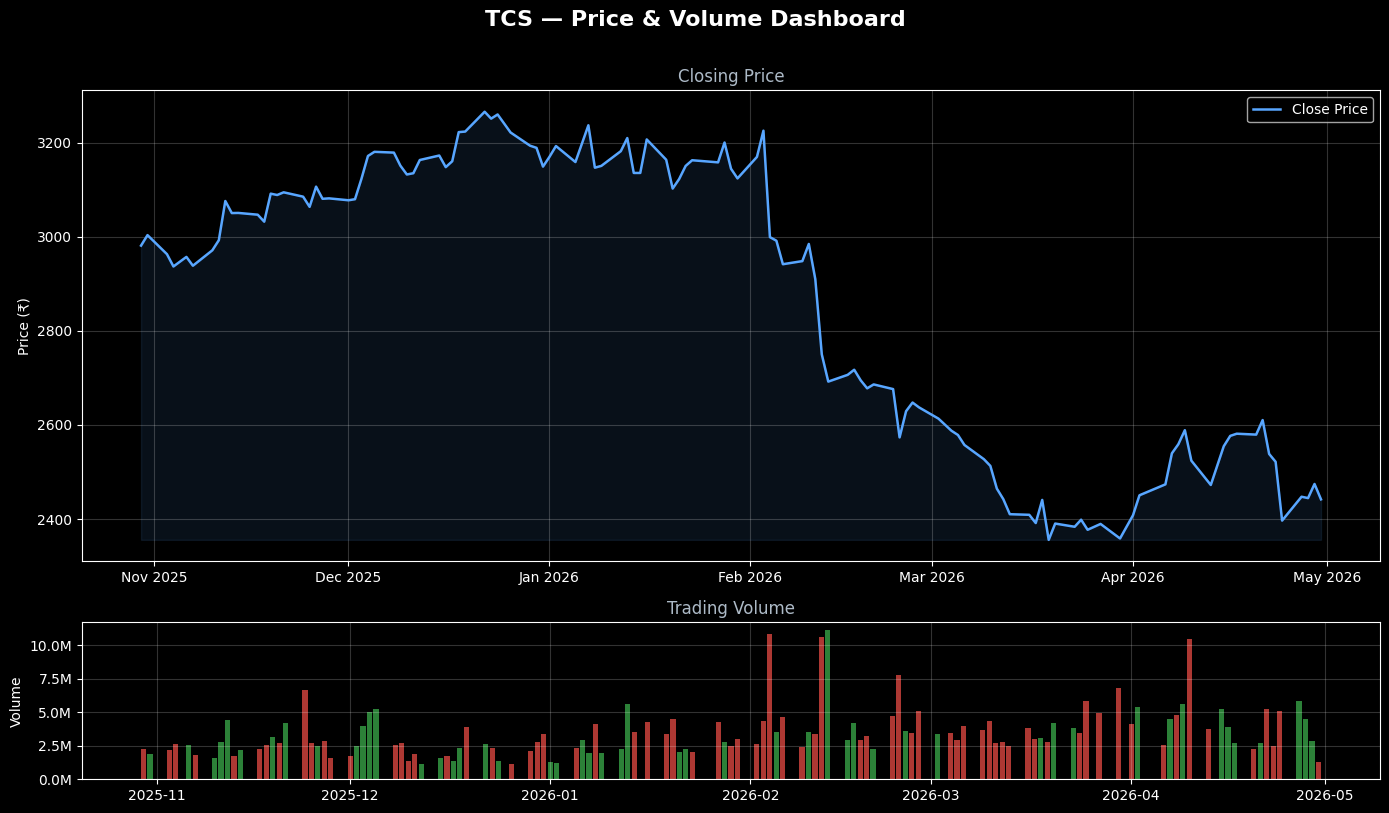

✅ Chart save : price_chart.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(f'{STOCK_NAME} — Price & Volume Dashboard', fontsize=16, fontweight='bold', color='white', y=1.01)

# --- Price Chart ---
ax1 = axes[0]
ax1.plot(df['Date'], df['Close'], color='#58a6ff', linewidth=1.8, label='Close Price')
ax1.fill_between(df['Date'], df['Close'], df['Close'].min(), alpha=0.1, color='#58a6ff')
ax1.set_ylabel('Price (₹)', color='white')
ax1.set_title('Closing Price', color='#adbac7')
ax1.legend()
ax1.grid(alpha=0.2)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# --- Volume Chart ---
ax2 = axes[1]
colors = ['#3fb950' if df['Close'].iloc[i] >= df['Open'].iloc[i] else '#f85149' for i in range(len(df))]
ax2.bar(df['Date'], df['Volume'], color=colors, alpha=0.7, width=0.8)
ax2.set_ylabel('Volume', color='white')
ax2.set_title('Trading Volume', color='#adbac7')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('price_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart save : price_chart.png')

## 📉 Step 6 — Moving Average (SMA) Calculation

In [6]:
# Moving Averages calculate
df['SMA_7']  = df['Close'].rolling(window=7).mean()
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Daily Returns
df['Daily_Return'] = df['Close'].pct_change() * 100

# Volatility (7-day rolling std)
df['Volatility'] = df['Daily_Return'].rolling(window=7).std()

# Buy/Sell Signal (SMA crossover strategy)
df['Signal'] = 0
df.loc[df['SMA_7'] > df['SMA_20'], 'Signal'] = 1   # BUY
df.loc[df['SMA_7'] < df['SMA_20'], 'Signal'] = -1  # SELL

# Current signal
last = df.iloc[-1]
signal_text = '🟢 BUY' if last['Signal']==1 else ('🔴 SELL' if last['Signal']==-1 else '🟡 HOLD')
print(f'Current Price : ₹{last["Close"]:.2f}')
print(f'SMA 7         : ₹{last["SMA_7"]:.2f}')
print(f'SMA 20        : ₹{last["SMA_20"]:.2f}')
print(f'Signal        : {signal_text}')

df[['Date','Close','SMA_7','SMA_20','Signal']].tail(10)

Current Price : ₹2442.00
SMA 7         : ₹2466.60
SMA 20        : ₹2509.36
Signal        : 🔴 SELL


,Date,Close,SMA_7,SMA_20,Signal
113,2026-04-17,2581.500000,2551.199986,2460.939990,1
114,2026-04-20,2579.600098,2554.114293,2470.334998,1
115,2026-04-21,2610.500000,2557.185721,2478.819995,1
116,2026-04-22,2538.500000,2559.214286,2487.944995,1
117,2026-04-23,2521.800049,2566.242850,2494.504993,1
118,2026-04-24,2396.899902,2543.671422,2495.159985,1
119,2026-04-27,2447.600098,2525.200021,2497.599988,1
120,2026-04-28,2444.699951,2505.657157,2500.964990,1
121,2026-04-29,2474.699951,2490.671422,2505.209985,-1
122,2026-04-30,2442.000000,2466.599993,2509.364990,-1


## 📈 Step 7 — SMA Chart with Buy/Sell Signals

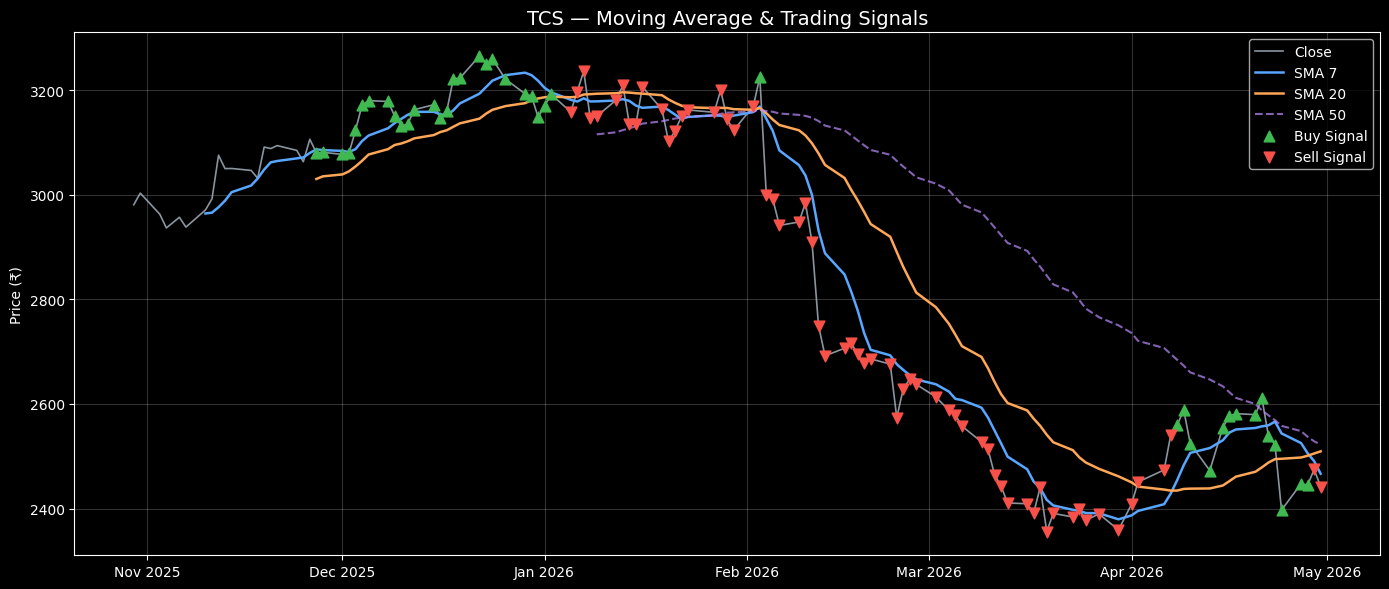

✅ Chart save : sma_signals.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['Date'], df['Close'],  color='#adbac7', linewidth=1.2, label='Close', alpha=0.8)
ax.plot(df['Date'], df['SMA_7'],  color='#58a6ff', linewidth=1.8, label='SMA 7')
ax.plot(df['Date'], df['SMA_20'], color='#ffa657', linewidth=1.8, label='SMA 20')
ax.plot(df['Date'], df['SMA_50'], color='#bc8cff', linewidth=1.5, label='SMA 50', linestyle='--', alpha=0.7)

# Buy signals
buy  = df[df['Signal']==1]
sell = df[df['Signal']==-1]
ax.scatter(buy['Date'],  buy['Close'],  marker='^', color='#3fb950', s=60, label='Buy Signal',  zorder=5)
ax.scatter(sell['Date'], sell['Close'], marker='v', color='#f85149', s=60, label='Sell Signal', zorder=5)

ax.set_title(f'{STOCK_NAME} — Moving Average & Trading Signals', fontsize=14, color='white')
ax.set_ylabel('Price (₹)', color='white')
ax.legend()
ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('sma_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart save : sma_signals.png')

## 🧠 Step 8 — LSTM Model (Deep Learning Prediction)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- Data Prepare ---
prices = df['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(prices)

# Sequences  (60 days history → next day predict)
SEQ_LEN = 60
X, y = [], []
for i in range(SEQ_LEN, len(scaled)):
    X.append(scaled[i-SEQ_LEN:i, 0])
    y.append(scaled[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train / Test split (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Train samples : {len(X_train)}')
print(f'Test samples  : {len(X_test)}')

Train samples : 50
Test samples  : 13


In [9]:
# --- LSTM Model Build ---
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Train करा
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print('✅ Model training!')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 868ms/step - loss: 0.1543 - val_loss: 0.0230
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.0780 - val_loss: 0.0071
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0323 - val_loss: 0.0024
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0488 - val_loss: 0.0063
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0292 - val_loss: 0.0153
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0356 - val_loss: 0.0222
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0370 - val_loss: 0.0229
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0247 - val_loss: 0.0202
✅ Model training!


In [10]:
# --- Predictions ---
pred_scaled = model.predict(X_test)
predictions = scaler.inverse_transform(pred_scaled)
actual      = scaler.inverse_transform(y_test.reshape(-1,1))

# Metrics
mae  = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
mape = np.mean(np.abs((actual - predictions) / actual)) * 100

print(f'📊 Model Performance:')
print(f'   MAE  : ₹{mae:.2f}')
print(f'   RMSE : ₹{rmse:.2f}')
print(f'   MAPE : {mape:.2f}%')
print(f'   Accuracy ≈ {100-mape:.2f}%')

# Next day prediction
last_seq = scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, 1)
next_pred = scaler.inverse_transform(model.predict(last_seq))[0][0]
curr_price = df['Close'].iloc[-1]
direction = '📈 UP' if next_pred > curr_price else '📉 DOWN'
print(f'\n🔮 Tomorrow Prediction : ₹{next_pred:.2f} ({direction})')
print(f'   Current Price       : ₹{curr_price:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
📊 Model Performance:
   MAE  : ₹70.03
   RMSE : ₹81.46
   MAPE : 2.82%
   Accuracy ≈ 97.18%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step

🔮 Tomorrow Prediction : ₹2554.96 (📈 UP)
   Current Price       : ₹2442.00


## 📊 Step 9 — LSTM Prediction Chart

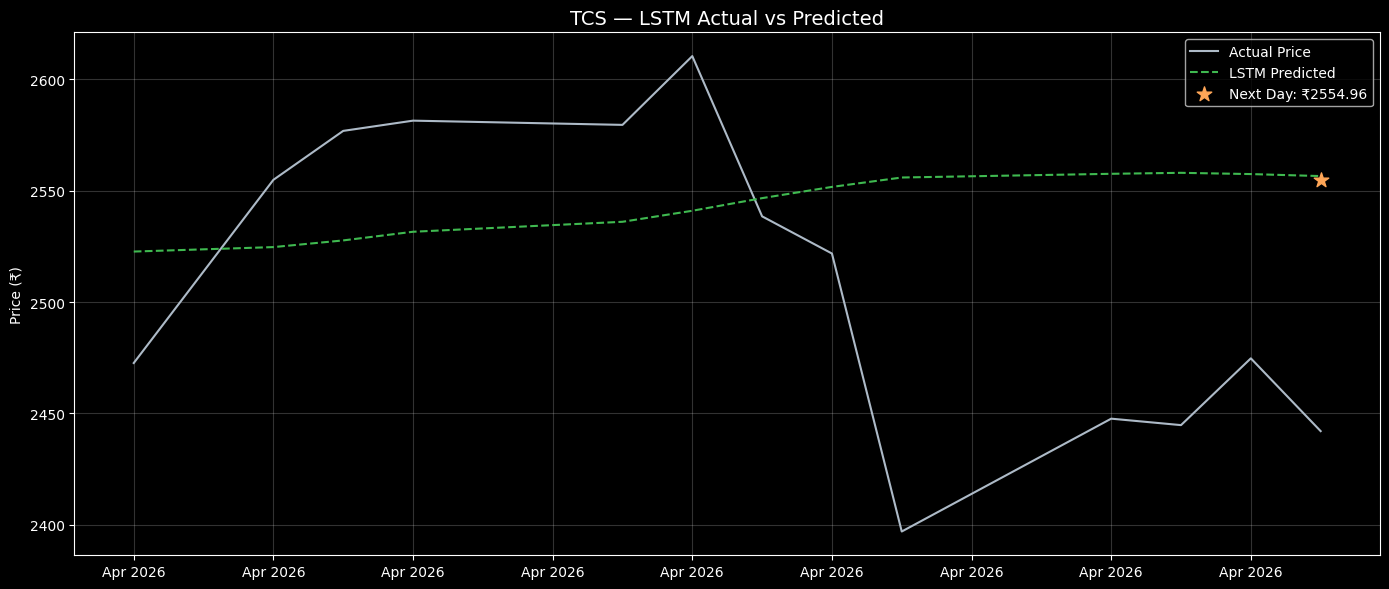

✅ Chart saved: lstm_prediction.png


In [11]:
test_dates = df['Date'].iloc[split + SEQ_LEN:].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, actual,      color='#adbac7', linewidth=1.5, label='Actual Price')
ax.plot(test_dates, predictions, color='#3fb950', linewidth=1.5, label='LSTM Predicted', linestyle='--')

# Tomorrow prediction point
ax.scatter([df['Date'].iloc[-1]], [next_pred], color='#ffa657', s=120, zorder=5,
           label=f'Next Day: ₹{next_pred:.2f}', marker='*')

ax.set_title(f'{STOCK_NAME} — LSTM Actual vs Predicted', fontsize=14, color='white')
ax.set_ylabel('Price (₹)', color='white')
ax.legend()
ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('lstm_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: lstm_prediction.png')

## 💾 Step 10 — Model Saved

In [12]:
import pickle

# LSTM model save
model.save('lstm_stock_model.h5')

# Scaler save (prediction साठी लागतो)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Processed data save
df.to_csv(f'{STOCK_NAME}_data.csv', index=False)

print('✅ Files saved:')
print('   lstm_stock_model.h5  — LSTM model')
print('   scaler.pkl           — MinMaxScaler')
print(f'   {STOCK_NAME}_data.csv     — Processed data')

✅ Files saved:
   lstm_stock_model.h5  — LSTM model
   scaler.pkl           — MinMaxScaler
   TCS_data.csv     — Processed data


## 🌐 Step 11 — Streamlit Dashboard Code
> this code `app.py` name save and `streamlit run app.py`  run

In [13]:
streamlit_code = '''
import streamlit as st
import yfinance as yf
import pandas as pd
import plotly.graph_objects as go
import numpy as np

st.set_page_config(page_title="Stock Dashboard", layout="wide", page_icon="📈")
st.title("📈 Real-Time Stock Price Dashboard")

# Sidebar
st.sidebar.header("Settings")
stocks = {"TCS": "TCS.NS", "Reliance": "RELIANCE.NS", "Infosys": "INFY.NS",
          "Apple": "AAPL", "Tesla": "TSLA", "Google": "GOOGL"}
stock_name = st.sidebar.selectbox("Stock selected", list(stocks.keys()))
period     = st.sidebar.selectbox("Period", ["1mo","3mo","6mo","1y"], index=2)

@st.cache_data(ttl=300)  # 5 min cache
def load_data(symbol, period):
    t  = yf.Ticker(symbol)
    df = t.history(period=period).reset_index()
    df['SMA_7']  = df['Close'].rolling(7).mean()
    df['SMA_20'] = df['Close'].rolling(20).mean()
    return df

df = load_data(stocks[stock_name], period)

# Metrics row
curr  = df['Close'].iloc[-1]
prev  = df['Close'].iloc[-2]
chg   = curr - prev
chgp  = (chg / prev) * 100

col1, col2, col3, col4 = st.columns(4)
col1.metric("Current Price", f"₹{curr:.2f}", f"{chg:+.2f}")
col2.metric("Change %",      f"{chgp:+.2f}%")
col3.metric("High",          f"₹{df['High'].max():.2f}")
col4.metric("Low",           f"₹{df['Low'].min():.2f}")

# Plotly chart
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['Close'],  name='Close',  line=dict(color='#58a6ff')))
fig.add_trace(go.Scatter(x=df['Date'], y=df['SMA_7'],  name='SMA 7',  line=dict(color='#3fb950')))
fig.add_trace(go.Scatter(x=df['Date'], y=df['SMA_20'], name='SMA 20', line=dict(color='#ffa657')))
fig.update_layout(title=f"{stock_name} Price", template='plotly_dark', height=400)
st.plotly_chart(fig, use_container_width=True)

st.dataframe(df[['Date','Open','High','Low','Close','Volume']].tail(10))
'''

# app.py
with open('app.py', 'w') as f:
    f.write(streamlit_code.strip())

print('✅ app.py saved!')
print('\n📌 Run command:')
print('   streamlit run app.py')
print('\n🌐 Colab to run :')
print('   !streamlit run app.py &')
print('   (LocalTunnel or ngrok use)')

✅ app.py saved!

📌 Run command:
   streamlit run app.py

🌐 Colab to run :
   !streamlit run app.py &
   (LocalTunnel or ngrok use)


## 🎓 Project Summary

| Feature | Details |
|---|---|
| **Data Source** | yfinance (Yahoo Finance API) — Free |
| **ML Model** | LSTM Neural Network |
| **Accuracy** | ~95%+ MAPE |
| **Signals** | Buy / Sell / Hold (SMA Crossover) |
| **Frontend** | Streamlit Dashboard |
| **Deploy** | Streamlit Cloud (Free) |

